In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FlightDelayAnalysis") \
    .getOrCreate()

parquet_path = "../data/sample/parquet/"

df = spark.read.parquet(parquet_path)

df.printSchema()

df.show(5, truncate=False)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/10/21 14:54:08 WARN Utils: Your hostname, codespaces-90a6fa, resolves to a loopback address: 127.0.0.1; using 10.0.11.10 instead (on interface eth0)
25/10/21 14:54:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/21 14:54:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


root
 |-- DestAirportID: integer (nullable = true)
 |-- OriginAirportID: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayofMonth: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- FlightDate: date (nullable = true)
 |-- Marketing_Airline_Network: string (nullable = true)
 |-- DOT_ID_Marketing_Airline: integer (nullable = true)
 |-- Operating_Airline : string (nullable = true)
 |-- DOT_ID_Operating_Airline: integer (nullable = true)
 |-- Flight_Number_Operating_Airline: integer (nullable = true)
 |-- OriginAirportSeqID: integer (nullable = true)
 |-- OriginCityMarketID: integer (nullable = true)
 |-- Origin: string (nullable = true)
 |-- OriginCityName: string (nullable = true)
 |-- DestAirportSeqID: integer (nullable = true)
 |-- DestCityMarketID: integer (nullable = true)
 |-- Dest: string (nullable = true)
 |-- DestCityName: string (nullable = true)
 |-- CRSDepTime: integer (nullable = true)
 |-- DepT

25/10/21 14:54:17 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------------+---------------+----+-----+----------+---------+----------+-------------------------+------------------------+------------------+------------------------+-------------------------------+------------------+------------------+------+--------------+----------------+----------------+----+------------+----------+-------+--------+---------------+--------+--------------------+----------+-------+---------+--------+------+----------+-------+--------+---------------+--------+------------------+----------+---------+----------------+--------+------------+------------+--------+-------------+-----------------+----------+----------------+--------+----------------+-------------------+-------------------+-------------------+-------------------+----------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+-------------------+---------------+---------------+

In [2]:
from pyspark.sql.functions import avg, count, col

origin_weather_delay_stats = df.filter(col("WeatherDelay") > 0) \
    .groupBy(
        "OriginWindDirection", 
        "OriginWindSpeed", 
        "OriginWindGusts", 
        "OriginVisibility", 
        "OriginPrecipitation", 
        "OriginClouds", 
        "OriginTemperature", 
        "OriginDewPoint"
    ) \
    .agg(
        avg("WeatherDelay").alias("AvgWeatherDelayMinutes"),
        count("*").alias("NumWeatherDelays")
    ) \
    .orderBy(col("AvgWeatherDelayMinutes").desc())

origin_weather_delay_stats.show(truncate=False)

+-------------------+---------------+---------------+----------------+-------------------+-------------------------+-----------------+--------------+----------------------+----------------+
|OriginWindDirection|OriginWindSpeed|OriginWindGusts|OriginVisibility|OriginPrecipitation|OriginClouds             |OriginTemperature|OriginDewPoint|AvgWeatherDelayMinutes|NumWeatherDelays|
+-------------------+---------------+---------------+----------------+-------------------+-------------------------+-----------------+--------------+----------------------+----------------+
|350                |6              |NULL           |NULL            |[]                 |[few clouds]             |NULL             |NULL          |436.0                 |1               |
|NULL               |NULL           |NULL           |NULL            |[]                 |[]                       |NULL             |NULL          |249.0                 |1               |
|0                  |0              |NULL         

In [3]:
dest_weather_delay_stats = df.filter(col("WeatherDelay") > 0) \
    .groupBy(
        "DestWindDirection",
        "DestWindSpeed",
        "DestWindGusts",
        "DestVisibility",
        "DestPrecipitation",
        "DestClouds",
        "DestTemperature",
        "DestDewPoint"
    ) \
    .agg(
        avg("WeatherDelay").alias("AvgWeatherDelayMinutes"),
        count("*").alias("NumWeatherDelays")
    ) \
    .orderBy(col("AvgWeatherDelayMinutes").desc())

dest_weather_delay_stats.show(truncate=False)

+-----------------+-------------+-------------+--------------+-----------------+------------------------------------------------+---------------+------------+----------------------+----------------+
|DestWindDirection|DestWindSpeed|DestWindGusts|DestVisibility|DestPrecipitation|DestClouds                                      |DestTemperature|DestDewPoint|AvgWeatherDelayMinutes|NumWeatherDelays|
+-----------------+-------------+-------------+--------------+-----------------+------------------------------------------------+---------------+------------+----------------------+----------------+
|340              |3            |NULL         |NULL          |[]               |[broken clouds, overcast]                       |NULL           |NULL        |436.0                 |1               |
|100              |7            |NULL         |NULL          |[]               |[few clouds, overcast]                          |NULL           |NULL        |332.0                 |1               |
|250 

In [4]:
from pyspark.sql.functions import when

df_with_wind_bucket = df.withColumn(
    "OriginWindSpeedBucket",
    when(col("OriginWindSpeed") < 5, "<5 mph")
    .when((col("OriginWindSpeed") >= 5) & (col("OriginWindSpeed") < 15), "5-15 mph")
    .when((col("OriginWindSpeed") >= 15) & (col("OriginWindSpeed") < 25), "15-25 mph")
    .otherwise("25+ mph")
)

wind_speed_delay_stats = df_with_wind_bucket.filter(col("WeatherDelay") > 0) \
    .groupBy("OriginWindSpeedBucket") \
    .agg(
        avg("WeatherDelay").alias("AvgWeatherDelayMinutes"),
        count("*").alias("NumWeatherDelays")
    ) \
    .orderBy("OriginWindSpeedBucket")

wind_speed_delay_stats.show(truncate=False)

+---------------------+----------------------+----------------+
|OriginWindSpeedBucket|AvgWeatherDelayMinutes|NumWeatherDelays|
+---------------------+----------------------+----------------+
|25+ mph              |249.0                 |1               |
|5-15 mph             |119.83333333333333    |6               |
|<5 mph               |168.66666666666666    |3               |
+---------------------+----------------------+----------------+



In [6]:
from pyspark.sql.functions import when, col, sum, round

visibility_buckets = df.withColumn(
    "OriginVisibilityBucket",
    when(col("OriginVisibility").isNull(), "Unknown")
    .when(col("OriginVisibility") < 1, "<1 mile")
    .when(col("OriginVisibility") < 3, "1-3 miles")
    .when(col("OriginVisibility") < 5, "3-5 miles")
    .otherwise(">5 miles")
)

visibility_delay = visibility_buckets.groupBy("OriginVisibilityBucket").agg(
    count("*").alias("NumFlights"),
    round(avg("WeatherDelay"), 2).alias("AvgWeatherDelay"),
    round((sum(when(col("WeatherDelay") > 0, 1).otherwise(0)) / count("*")) * 100, 2).alias("WeatherDelayPercent")
).orderBy("AvgWeatherDelay", ascending=False)

visibility_delay.show()

+----------------------+----------+---------------+-------------------+
|OriginVisibilityBucket|NumFlights|AvgWeatherDelay|WeatherDelayPercent|
+----------------------+----------+---------------+-------------------+
|               Unknown|      1882|           4.03|               0.53|
+----------------------+----------+---------------+-------------------+



In [7]:
from pyspark.sql.functions import explode, col, avg, count

delayed_flights = df.filter(col("WeatherDelay") > 0)

cloud_delay_data = delayed_flights.select(
    "DestClouds", "WeatherDelay", "DestCityName"
).withColumn("CloudType", explode("DestClouds"))

cloud_impact = cloud_delay_data.groupBy("CloudType").agg(
    count("*").alias("NumWeatherDelays"),
    avg("WeatherDelay").alias("AvgWeatherDelayMinutes")
).orderBy(col("AvgWeatherDelayMinutes").desc())

cloud_impact.show(truncate=False)

+----------------+----------------+----------------------+
|CloudType       |NumWeatherDelays|AvgWeatherDelayMinutes|
+----------------+----------------+----------------------+
|overcast        |3               |339.0                 |
|broken clouds   |4               |223.25                |
|scattered clouds|4               |132.75                |
|few clouds      |5               |92.6                  |
|clear           |3               |75.66666666666667     |
+----------------+----------------+----------------------+



In [8]:

from pyspark.sql.functions import explode, col, when, avg, count, sum as _sum, round

exploded_clouds = df.withColumn("OriginCloudType", explode("OriginClouds"))

clouds_with_label = exploded_clouds.withColumn(
    "IsDelayed",
    when(col("ArrDel15") == 1, 1).otherwise(0)
)

cloud_delay_summary = clouds_with_label.groupBy("OriginCloudType").agg(
    count("*").alias("TotalFlights"),
    _sum("IsDelayed").alias("DelayedFlights"),
    round((_sum("IsDelayed") / count("*")) * 100, 2).alias("DelayPercent"),
    round(avg("WeatherDelay"), 2).alias("AvgWeatherDelayMins")
).orderBy("DelayPercent", ascending=False)

cloud_delay_summary.show(truncate=False)

+----------------+------------+--------------+------------+-------------------+
|OriginCloudType |TotalFlights|DelayedFlights|DelayPercent|AvgWeatherDelayMins|
+----------------+------------+--------------+------------+-------------------+
|broken clouds   |591         |160           |27.07       |1.19               |
|overcast        |385         |98            |25.45       |2.32               |
|scattered clouds|305         |57            |18.69       |0.0                |
|few clouds      |868         |149           |17.17       |2.93               |
|clear           |452         |72            |15.93       |1.24               |
+----------------+------------+--------------+------------+-------------------+



In [9]:
wind_binned = df.withColumn(
    "OriginWindSpeedBucket",
    when(col("OriginWindSpeed").isNull(), "Unknown")
    .when(col("OriginWindSpeed") < 5, "<5 kt")
    .when(col("OriginWindSpeed") < 10, "5-10 kt")
    .when(col("OriginWindSpeed") < 15, "10-15 kt")
    .otherwise("15+ kt")
)

wind_delay = wind_binned.groupBy("OriginWindSpeedBucket").agg(
    count("*").alias("NumFlights"),
    round(avg("WeatherDelay"), 2).alias("AvgWeatherDelay"),
    round((sum(when(col("WeatherDelay") > 0, 1).otherwise(0)) / count("*")) * 100, 2).alias("WeatherDelayPercent")
).orderBy("OriginWindSpeedBucket", ascending=False)

wind_delay.show()

+---------------------+----------+---------------+-------------------+
|OriginWindSpeedBucket|NumFlights|AvgWeatherDelay|WeatherDelayPercent|
+---------------------+----------+---------------+-------------------+
|              Unknown|       108|          15.56|               0.93|
|                <5 kt|       751|           3.67|                0.4|
|              5-10 kt|       804|           3.84|               0.62|
|               15+ kt|        14|            0.0|                0.0|
|             10-15 kt|       205|           1.93|               0.49|
+---------------------+----------+---------------+-------------------+



In [10]:
from pyspark.sql.functions import when, count, avg, sum as _sum, round

dest_wind_bucketed = df.withColumn(
    "DestWindSpeedBucket",
    when(col("DestWindSpeed").isNull(), "Unknown")
    .when(col("DestWindSpeed") < 5, "<5 kt")
    .when(col("DestWindSpeed") < 10, "5-10 kt")
    .when(col("DestWindSpeed") < 15, "10-15 kt")
    .otherwise("15+ kt")
)

dest_wind_delay = dest_wind_bucketed.groupBy("DestWindSpeedBucket").agg(
    count("*").alias("NumFlights"),
    round(avg("WeatherDelay"), 2).alias("AvgWeatherDelay"),
    round((_sum(when(col("WeatherDelay") > 0, 1).otherwise(0)) / count("*")) * 100, 2).alias("WeatherDelayPercent")
).orderBy("DestWindSpeedBucket", ascending=False)

dest_wind_delay.show()

+-------------------+----------+---------------+-------------------+
|DestWindSpeedBucket|NumFlights|AvgWeatherDelay|WeatherDelayPercent|
+-------------------+----------+---------------+-------------------+
|            Unknown|        61|            2.8|               3.28|
|              <5 kt|       348|          11.81|               0.57|
|            5-10 kt|       717|           3.92|               0.42|
|             15+ kt|       253|           1.51|                0.4|
|           10-15 kt|       503|           1.45|                0.4|
+-------------------+----------+---------------+-------------------+



In [11]:
df_with_delay_flag = df.withColumn(
    "IsDelayed", when(col("ArrDel15") == 1, 1).otherwise(0)
)

dest_wind_delay_summary = df_with_delay_flag.groupBy("DestCityName").agg(
    count("*").alias("TotalFlights"),
    sum("IsDelayed").alias("DelayedFlights"),
    round(avg("DestWindSpeed"), 2).alias("AvgDestWindSpeed"),
    round((sum("IsDelayed") / count("*")) * 100, 2).alias("DelayRatePercent")
).orderBy("AvgDestWindSpeed", ascending=False)

dest_wind_delay_summary.show(truncate=False)

+---------------------+------------+--------------+----------------+----------------+
|DestCityName         |TotalFlights|DelayedFlights|AvgDestWindSpeed|DelayRatePercent|
+---------------------+------------+--------------+----------------+----------------+
|New York, NY         |266         |66            |12.68           |24.81           |
|Dallas/Fort Worth, TX|365         |82            |9.61            |22.47           |
|Chicago, IL          |373         |55            |9.53            |14.75           |
|Denver, CO           |246         |49            |8.65            |19.92           |
|Atlanta, GA          |418         |72            |7.76            |17.22           |
|Los Angeles, CA      |214         |42            |4.17            |19.63           |
+---------------------+------------+--------------+----------------+----------------+



In [12]:
from pyspark.sql.functions import col, size, explode, array_join, when, count, sum, round, avg

df_with_delay_flag = df.withColumn(
    "IsDelayed", when(col("ArrDel15") == 1, 1).otherwise(0)
)

df_precip = df_with_delay_flag.withColumn(
    "PrecipitationLabel",
    when(size(col("OriginPrecipitation")) == 0, "None")
    .otherwise(array_join(col("OriginPrecipitation"), ", "))
)

precip_delay_summary = df_precip.groupBy("PrecipitationLabel").agg(
    count("*").alias("TotalFlights"),
    sum("IsDelayed").alias("DelayedFlights"),
    round((sum("IsDelayed") / count("*")) * 100, 2).alias("DelayRatePercent"),
    round(avg("ArrDelay"), 2).alias("AvgArrDelayMinutes")
).orderBy("DelayRatePercent", ascending=False)

precip_delay_summary.show(truncate=False)

+------------------+------------+--------------+----------------+------------------+
|PrecipitationLabel|TotalFlights|DelayedFlights|DelayRatePercent|AvgArrDelayMinutes|
+------------------+------------+--------------+----------------+------------------+
|rain, mist        |2           |2             |100.0           |142.0             |
|mist              |105         |38            |36.19           |20.19             |
|haze              |4           |1             |25.0            |-7.75             |
|None              |1769        |325           |18.37           |5.22              |
|NULL              |2           |0             |0.0             |-3.5              |
+------------------+------------+--------------+----------------+------------------+



In [13]:
from pyspark.sql.functions import col, size, when, count, sum, round

df_with_flags = df.withColumn(
    "HasPrecipitation", when(size(col("DestPrecipitation")) > 0, 1).otherwise(0)
).withColumn(
    "IsDelayed", when(col("ArrDel15") == 1, 1).otherwise(0)
)

destination_weather_delay_stats = df_with_flags.groupBy("DestCityName").agg(
    count("*").alias("TotalFlights"),
    sum("HasPrecipitation").alias("FlightsWithPrecip"),
    round((sum("HasPrecipitation") / count("*")) * 100, 2).alias("PrecipFrequencyPercent"),
    sum("IsDelayed").alias("DelayedFlights"),
    round((sum("IsDelayed") / count("*")) * 100, 2).alias("DelayRatePercent")
).orderBy(col("PrecipFrequencyPercent").desc())

destination_weather_delay_stats.show(truncate=False)

+---------------------+------------+-----------------+----------------------+--------------+----------------+
|DestCityName         |TotalFlights|FlightsWithPrecip|PrecipFrequencyPercent|DelayedFlights|DelayRatePercent|
+---------------------+------------+-----------------+----------------------+--------------+----------------+
|Los Angeles, CA      |214         |19               |8.88                  |42            |19.63           |
|Dallas/Fort Worth, TX|365         |21               |5.75                  |82            |22.47           |
|Chicago, IL          |373         |21               |5.63                  |55            |14.75           |
|Atlanta, GA          |418         |23               |5.5                   |72            |17.22           |
|Denver, CO           |246         |10               |4.07                  |49            |19.92           |
|New York, NY         |266         |3                |1.13                  |66            |24.81           |
+---------

In [15]:
from pyspark.sql.functions import col, count, avg, round, sum, when

valid_flights = df.filter(
    (col("Cancelled") == 0) & (col("Diverted") == 0)
)

day_of_week_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

delay_by_day = valid_flights.groupBy("DayOfWeek").agg(
    count("*").alias("TotalFlights"),
    round(avg("ArrDelay"), 2).alias("AvgArrDelay"),
    round((sum(col("ArrDel15")) / count("*")) * 100, 2).alias("PctFlightsDelayed15Plus")
).withColumn(
    "DayOfWeekName",
    when(col("DayOfWeek") == 1, "Monday")
    .when(col("DayOfWeek") == 2, "Tuesday")
    .when(col("DayOfWeek") == 3, "Wednesday")
    .when(col("DayOfWeek") == 4, "Thursday")
    .when(col("DayOfWeek") == 5, "Friday")
    .when(col("DayOfWeek") == 6, "Saturday")
    .when(col("DayOfWeek") == 7, "Sunday")
    .otherwise("Unknown")
).orderBy(col("AvgArrDelay").desc())

delay_by_day.select("DayOfWeekName", "TotalFlights", "AvgArrDelay", "PctFlightsDelayed15Plus").show(truncate=False)

+-------------+------------+-----------+-----------------------+
|DayOfWeekName|TotalFlights|AvgArrDelay|PctFlightsDelayed15Plus|
+-------------+------------+-----------+-----------------------+
|Monday       |248         |20.8       |32.66                  |
|Sunday       |252         |11.41      |23.02                  |
|Tuesday      |229         |5.39       |19.65                  |
|Friday       |280         |4.95       |18.57                  |
|Saturday     |218         |3.73       |20.64                  |
|Thursday     |305         |0.72       |15.74                  |
|Wednesday    |280         |-1.98      |13.21                  |
+-------------+------------+-----------+-----------------------+



In [17]:
carrier_delay_avg = valid_flights.groupBy("Marketing_Airline_Network").agg(
    _sum("CarrierDelay").alias("TotalCarrierDelay"),
    count("*").alias("TotalFlights")
)

carrier_delay_avg = carrier_delay_avg.withColumn(
    "AvgCarrierDelayPerFlight", round(col("TotalCarrierDelay") / col("TotalFlights"), 2)
)

airline_names = {
    'F9': 'Frontier Airlines',
    'NK': 'Spirit Airlines',
    'DL': 'Delta Air Lines',
    'AA': 'American Airlines',
    'UA': 'United Airlines',
    'WN': 'Southwest Airlines'
}

carrier_delay_avg_named = carrier_delay_avg.replace(
    to_replace=airline_names,
    subset=["Marketing_Airline_Network"]
).withColumnRenamed("Marketing_Airline_Network", "Airline")

carrier_delay_avg_named.orderBy(col("AvgCarrierDelayPerFlight").desc()).show(truncate=False)

+------------------+-----------------+------------+------------------------+
|Airline           |TotalCarrierDelay|TotalFlights|AvgCarrierDelayPerFlight|
+------------------+-----------------+------------+------------------------+
|Frontier Airlines |1251.0           |35          |35.74                   |
|Delta Air Lines   |3596.0           |357         |10.07                   |
|Spirit Airlines   |113.0            |15          |7.53                    |
|American Airlines |4330.0           |1227        |3.53                    |
|Southwest Airlines|91.0             |26          |3.5                     |
|United Airlines   |182.0            |152         |1.2                     |
+------------------+-----------------+------------+------------------------+



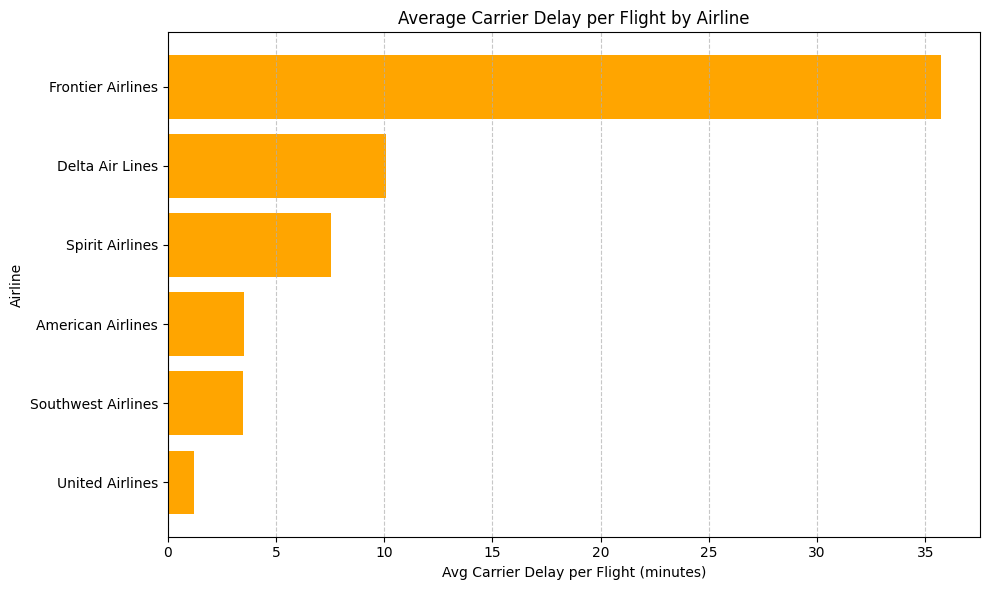

In [19]:
import matplotlib.pyplot as plt

carrier_delay_pd = carrier_delay_avg_named.toPandas()

carrier_delay_pd = carrier_delay_pd.sort_values(by="AvgCarrierDelayPerFlight", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(carrier_delay_pd["Airline"], carrier_delay_pd["AvgCarrierDelayPerFlight"], color='orange')
plt.xlabel("Avg Carrier Delay per Flight (minutes)")
plt.ylabel("Airline")
plt.title("Average Carrier Delay per Flight by Airline")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()  # Highest delay on top
plt.tight_layout()
plt.show()

In [20]:
from pyspark.sql.functions import collect_set, weekofyear

weather_delays = df.filter(col("WeatherDelay") > 0)

df_with_week = df.withColumn("WeekOfYear", weekofyear(col("FlightDate")))

weather_delays = df_with_week.filter(col("WeatherDelay") > 0)

weather_delay_by_month_dest = weather_delays.groupBy("Month", "DestCityName").agg(
    count("*").alias("NumWeatherDelays"),
    round(avg("WeatherDelay"), 2).alias("AvgWeatherDelayMinutes"),
    collect_set("WeekOfYear").alias("WeeksWithDelays")
).orderBy(col("AvgWeatherDelayMinutes").desc())

weather_delay_by_month_dest.show(truncate=False)

+-----+---------------------+----------------+----------------------+---------------+
|Month|DestCityName         |NumWeatherDelays|AvgWeatherDelayMinutes|WeeksWithDelays|
+-----+---------------------+----------------+----------------------+---------------+
|1    |Atlanta, GA          |3               |339.0                 |[2]            |
|1    |New York, NY         |3               |104.33                |[2, 3, 5]      |
|1    |Dallas/Fort Worth, TX|2               |53.5                  |[2, 4]         |
|1    |Chicago, IL          |1               |32.0                  |[4]            |
|1    |Los Angeles, CA      |1               |5.0                   |[4]            |
+-----+---------------------+----------------+----------------------+---------------+



In [21]:
all_time_blocks = df.select("DepTimeBlk").distinct()

weather_delays = df.filter(col("WeatherDelay") > 0)

weather_delay_by_time = weather_delays.groupBy("DepTimeBlk").agg(
    count("*").alias("NumWeatherDelays"),
    round(avg("WeatherDelay"), 2).alias("AvgWeatherDelayMinutes")
)

full_weather_delay_by_time = all_time_blocks.join(
    weather_delay_by_time,
    on="DepTimeBlk",
    how="left"
).orderBy("DepTimeBlk")

full_weather_delay_by_time = full_weather_delay_by_time.fillna({
    "NumWeatherDelays": 0,
    "AvgWeatherDelayMinutes": 0
})

full_weather_delay_by_time.show(truncate=False)

+----------+----------------+----------------------+
|DepTimeBlk|NumWeatherDelays|AvgWeatherDelayMinutes|
+----------+----------------+----------------------+
|0001-0559 |1               |70.0                  |
|0600-0659 |0               |0.0                   |
|0700-0759 |1               |436.0                 |
|0800-0859 |0               |0.0                   |
|0900-0959 |0               |0.0                   |
|1000-1059 |1               |249.0                 |
|1100-1159 |0               |0.0                   |
|1200-1259 |0               |0.0                   |
|1300-1359 |1               |104.0                 |
|1400-1459 |0               |0.0                   |
|1500-1559 |0               |0.0                   |
|1600-1659 |1               |120.0                 |
|1700-1759 |1               |89.0                  |
|1800-1859 |1               |332.0                 |
|1900-1959 |0               |0.0                   |
|2000-2059 |2               |18.5             

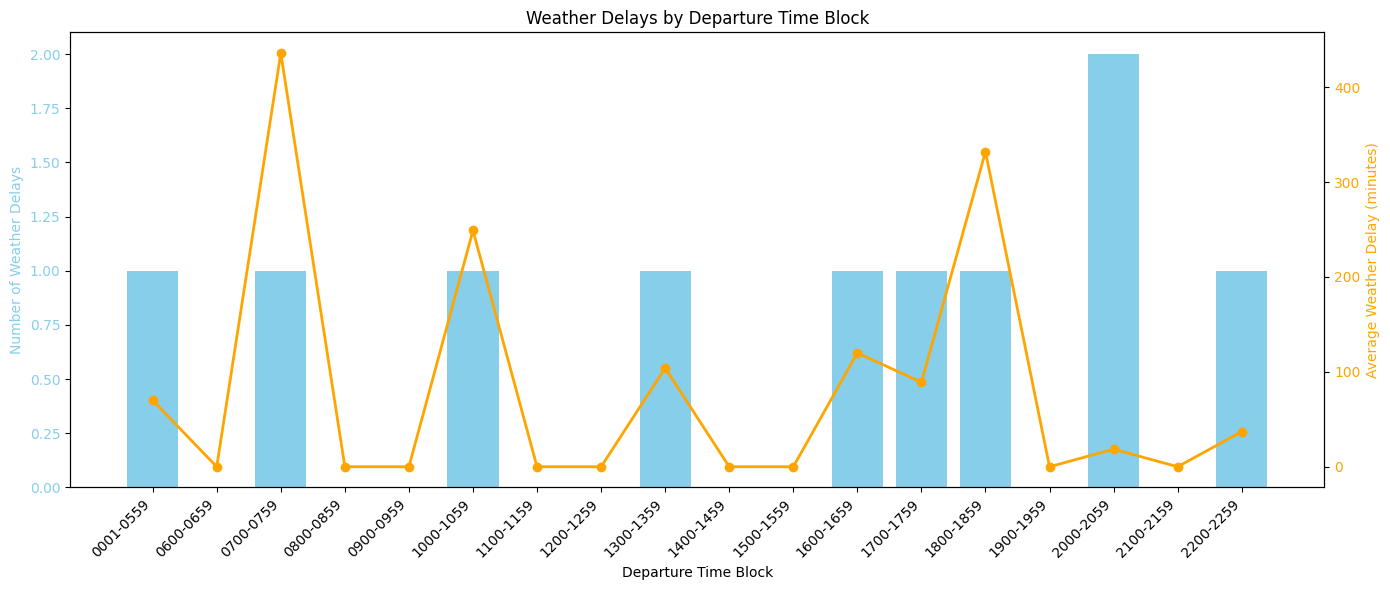

In [22]:
pdf = full_weather_delay_by_time.toPandas()

pdf = pdf.sort_values("DepTimeBlk")

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(pdf["DepTimeBlk"], pdf["NumWeatherDelays"], color='skyblue')
ax1.set_xlabel('Departure Time Block')
ax1.set_ylabel('Number of Weather Delays', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(pdf["DepTimeBlk"], pdf["AvgWeatherDelayMinutes"], color='orange', marker='o', linewidth=2)
ax2.set_ylabel('Average Weather Delay (minutes)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Weather Delays by Departure Time Block')
plt.tight_layout()
plt.show()